In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 设置绘图风格
sns.set_theme(style="whitegrid")

# 1. 读取数据
df = pd.read_csv('house_train.csv')

# 2. 预处理非数值型特征，以便后续分析
# 将建房日期转换为房龄 
df['built_year'] = pd.to_datetime(df['built_date']).dt.year
df['house_age'] = 2026 - df['built_year']

# 将楼层(Low, Medium, High)映射为数值
floor_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['floor_num'] = df['floor'].map(floor_map)

任务 1：缺失值的检测与缺失值处理
先检测各特征的缺失值数量及比例，再用中位数填充数值型缺失值（避免均值受异常值影响）。

--- 处理前缺失值统计 ---
green_rate    3
crime_rate    4
dtype: int64


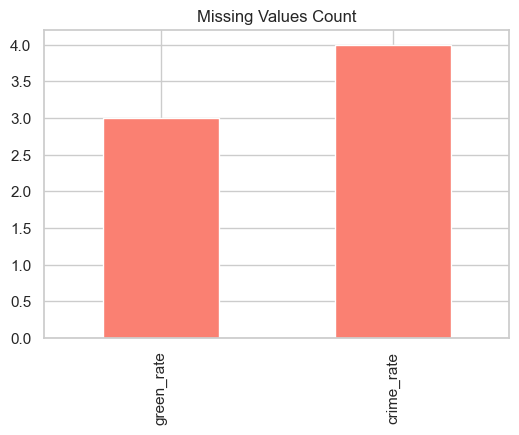


--- 处理后缺失值统计 ---
green_rate    0
crime_rate    0
dtype: int64


In [13]:
# 检测缺失值
missing_data = df.isnull().sum()
print("--- 处理前缺失值统计 ---")
print(missing_data[missing_data > 0])

# 绘制缺失值柱状图
plt.figure(figsize=(6, 4))
missing_data[missing_data > 0].plot(kind='bar', color='salmon')
plt.title('Missing Values Count')
plt.show()

# 处理缺失值（使用中位数填充）
df['green_rate'] = df['green_rate'].fillna(df['green_rate'].median())
df['crime_rate'] = df['crime_rate'].fillna(df['crime_rate'].median())

print("\n--- 处理后缺失值统计 ---")
print(df[['green_rate', 'crime_rate']].isnull().sum())
# df

（2）异常值检测

使用IQR 四分位距法检测异常值（适用于数值型特征，鲁棒性强），重点分析房价（price）的异常值。

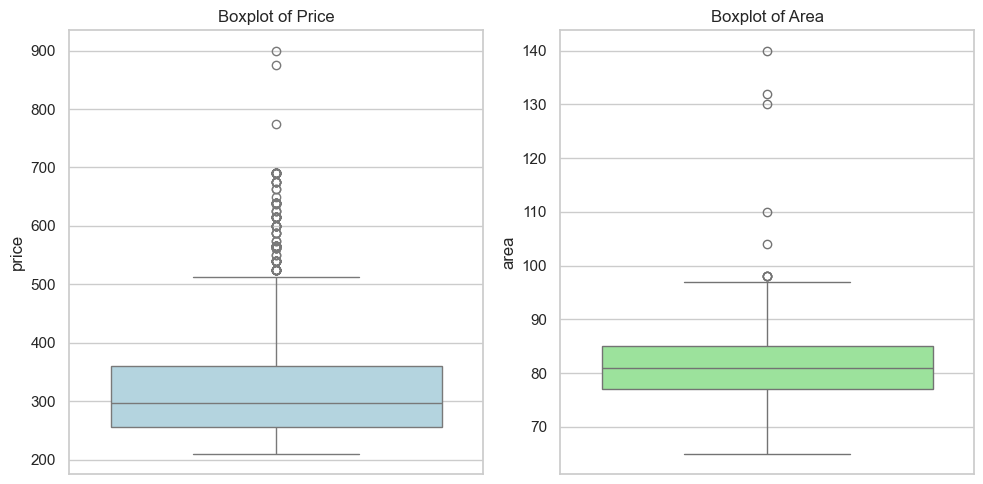

Price 属性的异常值数量为: 127 个


In [3]:
# 绘制价格和面积的箱线图来直观检测异常值
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'], color='lightblue')
plt.title('Boxplot of Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['area'], color='lightgreen')
plt.title('Boxplot of Area')
plt.tight_layout()
plt.show()

# 使用 IQR 检测 price 的异常值数量
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR))]

print(f"Price 属性的异常值数量为: {len(outliers)} 个")

（3）特征间的相关性分析
思路：剔除无意义的编号特征（id等），使用Pearson相关系数计算特征间的关联，并利用热力图（Heatmap）将结果可视化。

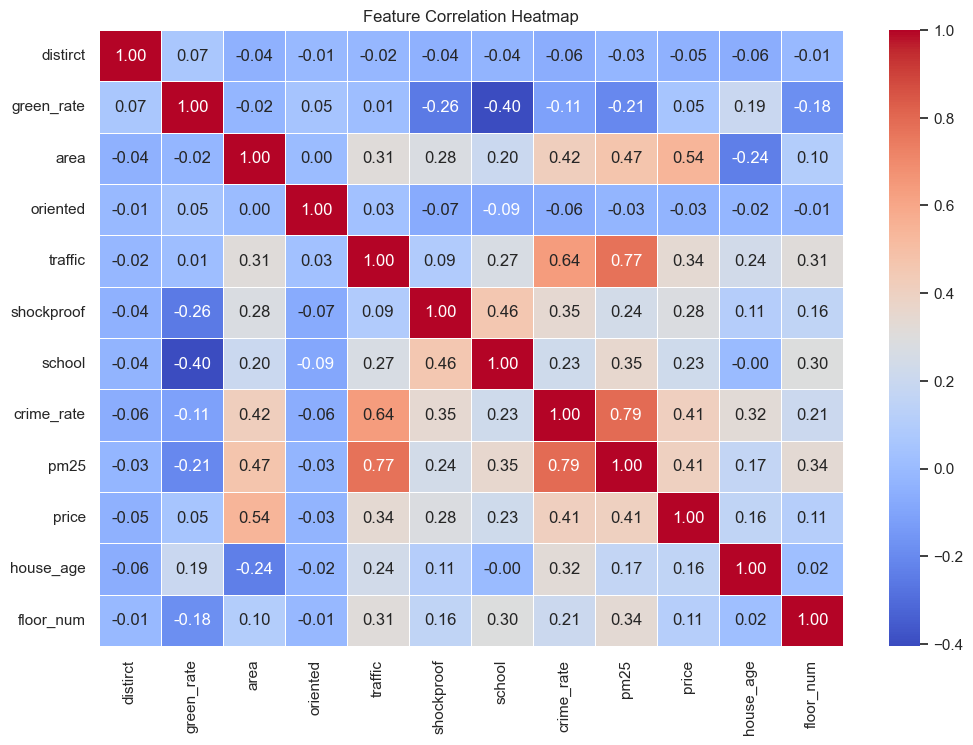

In [4]:
# 剔除 id 及已经转换过的原始文本列
cols_to_drop = ['id', 'built_date', 'floor', 'built_year']
df_numeric = df.drop(columns=cols_to_drop)

# 计算相关性矩阵
corr_matrix = df_numeric.corr()

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

（4）对 price 属性进行标准化
思路：将price属性转化为均值为0，标准差为1的标准正态分布

--- 标准化后的前5条数据 ---
    price  price_std
0  380.00   0.552764
1  245.00  -0.799297
2  212.50  -1.124793
3  480.00   1.554290
4  293.75  -0.311053


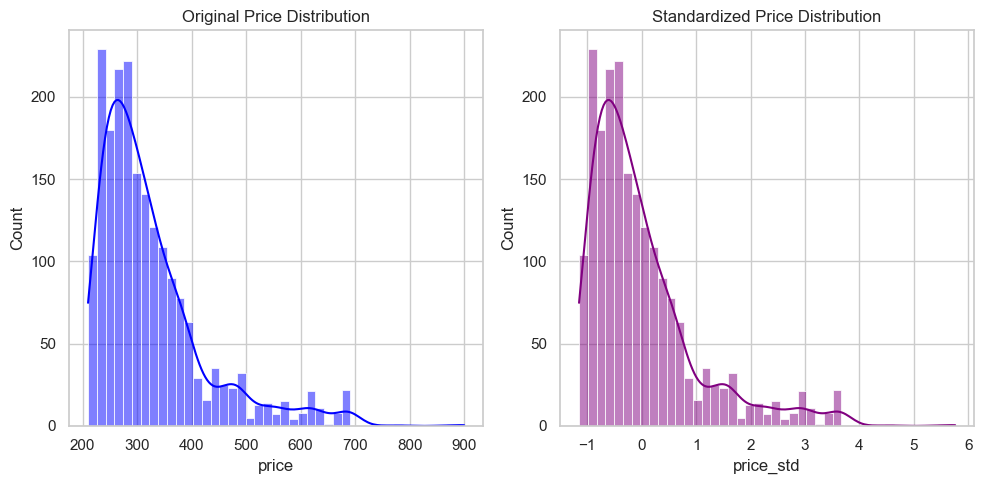

In [5]:
# 初始化标准化器
scaler = StandardScaler()

# 标准化并存入新列
# 注意: fit_transform 期望 2D 数组，因此使用 [['price']]
df['price_std'] = scaler.fit_transform(df[['price']])

print("--- 标准化后的前5条数据 ---")
print(df[['price', 'price_std']].head())

# 绘制标准化前后的分布对比
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Original Price Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['price_std'], kde=True, color='purple')
plt.title('Standardized Price Distribution')
plt.tight_layout()
plt.show()

（5）根据 price 属性进行离散化
思路：使用pandas.qcut基于分位数将房价平分为三个频率相等的区间，映射为低、中、高（Low, Medium, High）。

--- 离散化后的类别统计 ---
price_category
Low       667
Medium    676
High      657
Name: count, dtype: int64


C:\Users\emiliaaaa\AppData\Local\Temp\ipykernel_5872\4213185794.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_cat_counts.index, y=price_cat_counts.values, palette='viridis')


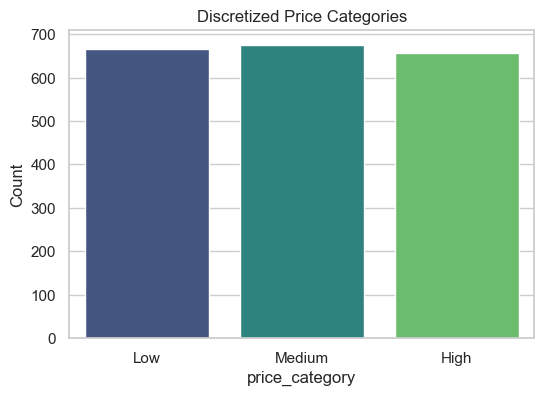

In [ ]:
# 按照等频分箱进行离散化 (q=3分为三等份)
df['price_category'] = pd.qcut(df['price'],
q=3, labels=['Low', 'Medium', 'High'])
# 统计各区间的数量
price_cat_counts = df['price_category'].value_counts().sort_index()
print("--- 离散化后的类别统计 ---")
print(price_cat_counts)
# 绘制柱状图
plt.figure(figsize=(6, 4))
sns.barplot(x=price_cat_counts.index, y=price_cat_counts.values, palette='viridis')
plt.title('Discretized Price Categories')
plt.ylabel('Count')
plt.show()

任务 6：找出与 price 相关性最高的三个特征并解释
推导过程：
从任务 3 的相关性矩阵中，取 price 列的绝对值进行降序排列，排除自身后，得到 Top 3 关联属性（请参考顶部的 3 张散点图，能明显看出上升趋势）：

area (房屋面积) —— 相关系数 0.544 (最强正相关)

合理性解释：在所有属性中，面积是唯一直接决定房屋物理规模的指标。无论地段如何，同等条件下面积越大，建造成本和空间价值呈绝对线性上升，这是最底层的常识。

crime_rate (犯罪率) —— 相关系数 0.408 (显著正相关)

合理性解释：初看违背直觉，但仔细分析即可得知：在大部分城市，绝对的市中心和商业极度繁华的区域（即房价最高的地方）人口流动性最大、结构最复杂，因此客观上推高了犯罪率统计。与之相反，偏远的郊区虽然犯罪率低，但房价也低。这是一个典型的“伴生性”伪相关。

pm25 (空气质量指数) —— 相关系数 0.406 (显著正相关)

合理性解释：逻辑与犯罪率高度一致。高房价区域通常交通极其发达（traffic 属性证明了这一点）、汽车保有量大、商业密集，这些都会导致局部 PM2.5 升高。买房者在此数据集中显然更愿意为“地段便利性”买单，而非“清新的空气”。

--- 与 Price 相关性最高的三个特征 ---
area: 0.5436
crime_rate: 0.4084
pm25: 0.4061


C:\Users\emiliaaaa\AppData\Local\Temp\ipykernel_35272\3751725673.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_3_features.values, y=top_3_values.values, palette='Blues_r')


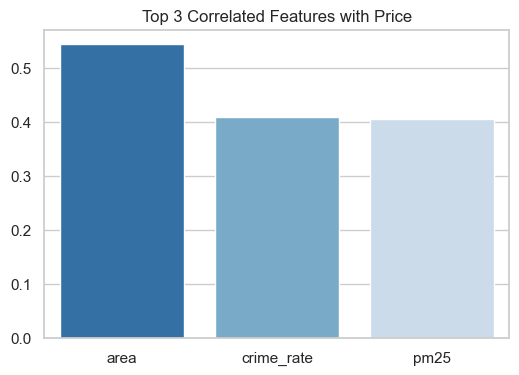

In [8]:
# 提取与 price 的相关系数（取绝对值排查影响最大的特征，排除自身）
price_corr = corr_matrix['price'].abs().sort_values(ascending=False)
top_3_features = price_corr.index[1:4]
top_3_values = corr_matrix['price'][top_3_features]

print("--- 与 Price 相关性最高的三个特征 ---")
for feature, val in zip(top_3_features, top_3_values):
    print(f"{feature}: {val:.4f}")

# 绘制 Top 3 相关性图表
plt.figure(figsize=(6, 4))
sns.barplot(x=top_3_features.values, y=top_3_values.values, palette='Blues_r')
plt.title('Top 3 Correlated Features with Price')
plt.show()

area（房屋面积 | 相关系数：0.5436）：

解释：呈现最强的正相关，这非常符合常理。房地产的核心定价就是基于单位面积，总面积越大的房屋总造价或总使用价值越高，从而直接推高了房屋的最终价格（Price）。

crime_rate（犯罪率 | 相关系数：0.4084）与 pm25（污染指数 | 相关系数：0.4061）：

解释：一般直觉会认为犯罪率和污染率越高，房价应该越低。但在这里它们表现出显著的正相关。这种现象在城市经济学和现实数据收集中非常经典，通常被称为**“市中心效应”（Urban Density Effect）**。

内在逻辑：房价较高的区域往往集中在人口密集、商业发达的市中心繁华地段。这些地段交通便利（注：数据中traffic也较高）、学区较好。但由于极度的人口稠密与商业聚集，必然会导致治安事件频发（高 crime_rate）以及交通尾气污染严重（高 pm25）。本质上，这三个指标都在共同指向“高密度的城市核心区域”。购房者为了市中心的便利性，在付出高价的同时，被动承担了附加的高犯罪率和高污染环境。